<a href="https://colab.research.google.com/github/scattering/paper-ai-diffraction/blob/notebook-test/notebooks/reviewer_walkthrough_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reviewer Walkthrough: Single-Pattern Extinction-Group Inference (Google Colab)

This notebook is the Colab-friendly version of `notebooks/reviewer_walkthrough.ipynb`. It accepts a plain CSV with `2theta` and `intensity`, normalizes and interpolates the pattern onto the model grid, runs extinction-group inference from a released checkpoint, and optionally compares the prediction to a supplied true space group on the condensed extinction-group DAG.

The scientific logic is identical to the reference reviewer notebook; only the setup has been adapted for Colab (pip install and direct file uploads instead of a conda environment).

The repo also ships with two real `RRUFF-325` examples that are cloned alongside the package:

- one correct case under the final mixed paper model
- one failure case under the same model

## Setup

The next cell:

1. Installs the runtime dependencies with `pip`.
2. Clones the paper repo so that the bundled configs, lookups, topology JSON, reviewer example CSVs, and precomputed benchmark summary are available on the Colab VM.
3. Installs the `paper_ai_diffraction` package in editable mode from the clone.

Colab runtimes already include `torch`, `numpy`, `pandas`, `matplotlib`, and usually `h5py`, so these installs will like be a no-op. The repo's `pyproject.toml` intentionally declares no runtime dependencies, so the dependency list is explicit here.

In [1]:
!pip install -q numpy pandas matplotlib h5py torch
!git clone --depth 1 -b notebook-test https://github.com/scattering/paper-ai-diffraction.git /content/paper-ai-diffraction
%cd /content/paper-ai-diffraction
!pip install -q -e .

Cloning into '/content/paper-ai-diffraction'...
remote: Enumerating objects: 127, done.
remote: Counting objects: 100% (127/127), done.
remote: Compressing objects: 100% (99/99), done.
remote: Total 127 (delta 27), reused 89 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (127/127), 236.92 KiB | 5.15 MiB/s, done.
Resolving deltas: 100% (27/27), done.
/content/paper-ai-diffraction
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for paper-ai-diffraction (pyproject.toml) ... done


In [ ]:
import os
os.kill(os.getpid(), 9)

## Upload The Released Checkpoint

The checkpoint is not bundled in the repo. Download a checkpoint from the paper's Zenodo record, then upload it to this Colab runtime. Two options:

- Drag-and-drop the file into the Colab **Files** panel (left sidebar), then point `CHECKPOINT_PATH` below at its location (default `/content/<checkpoint-name>.pth`).
- Or run the next cell, which opens a browser file-picker via `google.colab.files.upload()` and saves the file to `/content/`.

If you want paper-faithful calibrated inference, also upload a trainready HDF5 and set `PRIOR_H5` in the configuration cell further below. Otherwise the notebook runs in checkpoint-only mode.

In [1]:
# Optional interactive upload. Skip if you dragged the file into the Files panel.
from pathlib import Path

try:
    from google.colab import files  # type: ignore
    uploaded = files.upload()
    if uploaded:
        uploaded_name = next(iter(uploaded))
        uploaded_path = Path('/content') / uploaded_name
        print('Uploaded to', uploaded_path)
except ModuleNotFoundError:
    print('Not running on Colab; skip this cell and set CHECKPOINT_PATH manually.')

Saving xrd_model_82ept35h_best.pth to xrd_model_82ept35h_best.pth
Uploaded to /content/xrd_model_82ept35h_best.pth


## Imports And Model Bundle

Edit `CHECKPOINT_PATH` if you uploaded the checkpoint under a different name. The other paths resolve to files that were just cloned with the repo.

In [2]:
%matplotlib inline
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

from paper_ai_diffraction.reviewer import (
    build_model_bundle,
    describe_topology_relation,
    infer_single_pattern,
    load_example_manifest,
    load_example_metadata,
    load_precomputed_benchmark_summary,
    load_topology_assets,
    normalize_and_interpolate_pattern,
    plot_pattern_overlay,
    plot_precomputed_summary,
    plot_topk_probabilities,
    plot_topology_path,
    read_pattern_csv,
    space_group_to_ext_group,
)

In [3]:
%cd /content/paper-ai-diffraction
cwd = Path.cwd().resolve()
REPO_ROOT = next((candidate for candidate in [cwd, *cwd.parents] if (candidate / 'configs').exists()), None)
if REPO_ROOT is None:
    raise FileNotFoundError(f'Could not locate repo root from {cwd}')

CHECKPOINT_PATH = Path('/content/xrd_model_82ept35h_best.pth')  # edit to match your checkpoint name
CONFIG_PATH = REPO_ROOT / 'configs/final_mixed_2500k_dualsource.json'
PRECOMPUTED_SUMMARY_PATH = REPO_ROOT / 'results/reviewer/rruff325_precomputed_inference.json'
PRIOR_H5 = None  # optionally set to an uploaded trainready HDF5 path for paper-faithful calibrated inference
DEVICE = None    # set to 'cpu' or 'cuda' if you want to force a device
DECODER = 'aux_bayes'  # falls back automatically if PRIOR_H5 is not supplied
AUX_TEMPERATURE = 5.0

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f'Checkpoint not found at {CHECKPOINT_PATH}. Upload it first and update CHECKPOINT_PATH.'
    )

bundle = build_model_bundle(
    checkpoint_path=CHECKPOINT_PATH,
    config_path=CONFIG_PATH,
    device=DEVICE,
    prior_h5_path=PRIOR_H5,
)
topology = load_topology_assets()
bundle.config['two_theta_min'], bundle.config['two_theta_max'], bundle.config['spec_length']

/content/paper-ai-diffraction


(5.0, 90.0, 8501)

## Select A Pattern CSV

Three options:

- Keep the default `PATTERN_CSV` pointing at the shipped correct case.
- Comment/uncomment to swap to the shipped failure case.
- Upload your own CSV via the Colab **Files** panel (or `google.colab.files.upload()`) and set `PATTERN_CSV = Path('/content/your_pattern.csv')`.

Required CSV columns: `2theta` (or `two_theta`) and `intensity`. The notebook handles sorting, normalization, and interpolation onto the model grid internally.

In [4]:
example_dir = REPO_ROOT / 'assets/reviewer_examples'
example_manifest = load_example_manifest(example_dir / 'manifest.json')
example_manifest

{'benchmark_h5_basename': 'RRUFF_usable_plus_recoverable_325_with_labels_maxnorm.hdf5',
 'failure_json': 'results/mixed2500k_compare_325_failure_modes_655279.json',
 'model_key': None,
 'metadata_csv': 'reviewer_case_metadata.csv',
 'examples': {'correct_case': {'csv_path': 'assets/reviewer_examples/correct_case_015_Arsenopyrite__R050071-1__6130.csv',
   'json_path': 'assets/reviewer_examples/correct_case_015_Arsenopyrite__R050071-1__6130.json',
   'case_id': 'Arsenopyrite__R050071-1__6130',
   'true_eg': 99},
  'failure_case': {'csv_path': 'assets/reviewer_examples/failure_case_000_Actinolite__R050336-1__5330.csv',
   'json_path': 'assets/reviewer_examples/failure_case_000_Actinolite__R050336-1__5330.json',
   'case_id': 'Actinolite__R050336-1__5330',
   'true_eg': 5}}}

In [5]:
example_csvs = sorted(list(example_dir.glob('correct_case_*.csv')) + list(example_dir.glob('failure_case_*.csv')))
PATTERN_CSV = next(example_dir.glob('correct_case_*.csv'))
# PATTERN_CSV = next(example_dir.glob('failure_case_*.csv'))
# PATTERN_CSV = Path('/content/your_pattern.csv')
selected_metadata = load_example_metadata(PATTERN_CSV) if PATTERN_CSV.parent == example_dir and PATTERN_CSV.with_suffix('.json').exists() else None
PATTERN_CSV

PosixPath('/content/paper-ai-diffraction/assets/reviewer_examples/correct_case_015_Arsenopyrite__R050071-1__6130.csv')

In [6]:
df = read_pattern_csv(PATTERN_CSV)
prep = normalize_and_interpolate_pattern(
    df,
    two_theta_min=float(bundle.config.get('two_theta_min', 5.0)),
    two_theta_max=float(bundle.config.get('two_theta_max', 90.0)),
    spec_length=int(bundle.config['spec_length']),
)
prep['warnings']

[]

### Preprocessing Plot

Color guide:
- Blue line: cleaned source CSV after normalization.
- Orange line: the same pattern after interpolation onto the model's fixed 2theta grid.

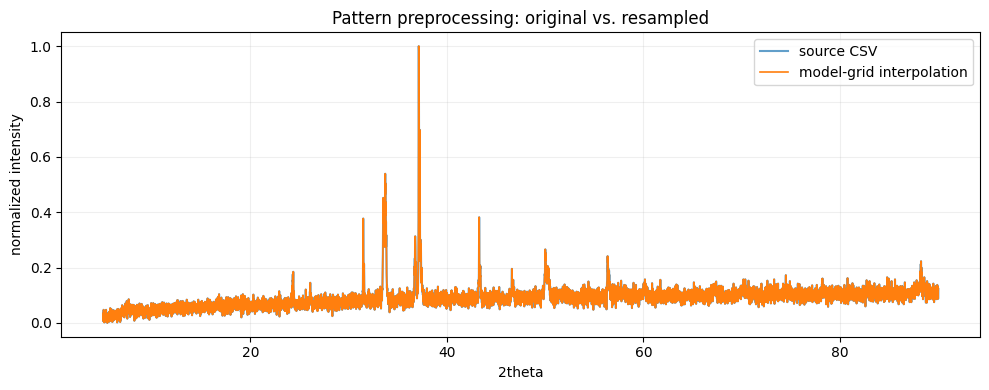

In [7]:
fig, ax = plot_pattern_overlay(prep)
plt.show()

if prep['warnings']:
    print('Warnings:')
    for warning in prep['warnings']:
        print('-', warning)

In [8]:
result = infer_single_pattern(
    bundle,
    prep['target_intensity'],
    aux_temperature=AUX_TEMPERATURE,
    decoder=DECODER,
    prior_h5_path=PRIOR_H5,
)
result

{'selected_decoder': 'aux_raw',
 'top1_eg': 99,
 'top1_symbol': 'C - c - (equiv: C c - -, B - - b, B b - -, A - - a, A - a -)',
 'top1_crystal_system': 'Orthorhombic',
 'top1_candidate_space_groups': [1, 2],
 'decoders': {'aux_raw': {'top5_eg': [99, 5, 4, 93, 6],
   'top5_prob': [0.7145917415618896,
    0.06274686008691788,
    0.045009221881628036,
    0.04049420356750488,
    0.02061714418232441]},
  'split_raw': {'top5_eg': [32, 69, 93, 31, 70],
   'top5_prob': [0.21815748512744904,
    0.19624626636505127,
    0.19624626636505127,
    0.06320402771234512,
    0.05685596913099289]}}}

## Interpret The Prediction

The model predicts an extinction group, not a unique space group. The compatible space groups listed below are the crystallographically valid space groups for that predicted extinction group.

Plot color guide:
- In the top-k bar chart, dark blue marks the top-1 extinction-group prediction.
- Light blue marks the lower-ranked candidates in the displayed top-k list.

,rank,extinction_group,probability
0,1,99,0.714592
1,2,5,0.062747
2,3,4,0.045009
3,4,93,0.040494
4,5,6,0.020617


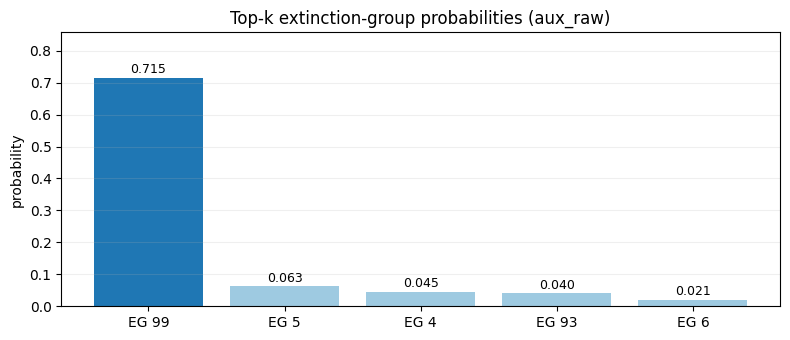

In [9]:
selected = result['decoders'][result['selected_decoder']]
display(pd.DataFrame({
    'rank': range(1, len(selected['top5_eg']) + 1),
    'extinction_group': selected['top5_eg'],
    'probability': selected['top5_prob'],
}))

fig, ax = plot_topk_probabilities(result)
plt.show()

In [10]:
print('Top-1 extinction group:', result['top1_eg'])
print('Canonical symbol:', result['top1_symbol'])
print('Crystal system:', result['top1_crystal_system'])
print('Compatible space groups:', result['top1_candidate_space_groups'])

Top-1 extinction group: 99
Canonical symbol: C - c - (equiv: C c - -, B - - b, B b - -, A - - a, A - a -)
Crystal system: Orthorhombic
Compatible space groups: [1, 2]


## Optional Truth-Aware Topology Check

If the true space group or extinction group is known, this section compares the model prediction to the benchmark truth on the condensed extinction-group DAG.

Plot color guide:
- Green node: true extinction group.
- Red node: predicted extinction group.
- Gray nodes: intermediate condensed-DAG nodes on the shortest path between them.

True space group: 2
True space group symbol: P-1
Resolved true extinction group: 99
Truth source: benchmark_true_eg
Topology relation: exact
Shortest-path distance: 0
Condensed DAG path: ['98']


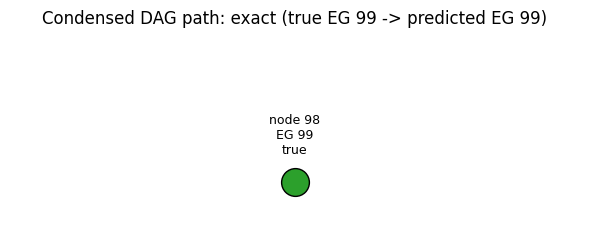

In [11]:
TRUE_SPACE_GROUP = None  # override for an arbitrary uploaded CSV, e.g. 19
TRUE_EG = None           # optional direct override if you know the true extinction group instead

if selected_metadata is not None:
    TRUE_SPACE_GROUP = selected_metadata.get('true_space_group', TRUE_SPACE_GROUP)
    TRUE_EG = selected_metadata.get('true_eg', TRUE_EG)

truth_source = None
resolved_true_eg = None
sg_mapped_eg = None

if TRUE_EG is not None:
    resolved_true_eg = int(TRUE_EG)
    truth_source = 'benchmark_true_eg'

if TRUE_SPACE_GROUP is not None:
    sg_mapped_eg = space_group_to_ext_group(int(TRUE_SPACE_GROUP), bundle)
    if resolved_true_eg is None:
        resolved_true_eg = sg_mapped_eg
        truth_source = 'space_group'
    elif sg_mapped_eg is not None and int(sg_mapped_eg) != int(resolved_true_eg):
        print('Warning: benchmark true EG and SG->EG mapping disagree; using benchmark true EG for topology.')

if resolved_true_eg is None:
    print('No truth provided. Set TRUE_SPACE_GROUP or TRUE_EG to compare topology.')
else:
    relation = describe_topology_relation(result['top1_eg'], resolved_true_eg, topology)
    print('True space group:', TRUE_SPACE_GROUP)
    if selected_metadata is not None and selected_metadata.get('true_space_group_symbol'):
        print('True space group symbol:', selected_metadata['true_space_group_symbol'])
    print('Resolved true extinction group:', resolved_true_eg)
    print('Truth source:', truth_source)
    print('Topology relation:', relation['relation'])
    print('Shortest-path distance:', relation['distance'])
    print('Condensed DAG path:', relation['path'])
    fig, ax = plot_topology_path(
        relation,
        topology,
        true_eg=resolved_true_eg,
        pred_eg=result['top1_eg'],
    )
    plt.show()

## Included Worked Examples

The paired metadata JSONs record the benchmark index, mineral name, true extinction group, and the stored paper-model top-5 summary for the two shipped `RRUFF-325` examples.

In [12]:
worked_example_csvs = sorted(list(example_dir.glob('correct_case_*.csv')) + list(example_dir.glob('failure_case_*.csv')))
for csv_path in worked_example_csvs:
    meta = load_example_metadata(csv_path)
    print('\n===', csv_path.name, '===')
    print(json.dumps(meta, indent=2))


=== correct_case_015_Arsenopyrite__R050071-1__6130.csv ===
{
  "tag": "correct_case",
  "benchmark_index": 15,
  "case_id": "Arsenopyrite__R050071-1__6130",
  "mineral": "Arsenopyrite",
  "severity": "recoverable",
  "fit_bucket": "fail",
  "rwp": 0.12289926409721375,
  "true_eg": 99,
  "true_space_group": 2,
  "true_space_group_symbol": "P-1",
  "true_space_group_source": "rruff_fit_dif",
  "paper_model_summary": {
    "index": 15,
    "true_eg": 99,
    "pred_eg": 99,
    "top5_eg": [
      99,
      4,
      6,
      5,
      17
    ],
    "correct": true
  },
  "csv_path": "assets/reviewer_examples/correct_case_015_Arsenopyrite__R050071-1__6130.csv"
}

=== failure_case_000_Actinolite__R050336-1__5330.csv ===
{
  "tag": "failure_case",
  "benchmark_index": 0,
  "case_id": "Actinolite__R050336-1__5330",
  "mineral": "Actinolite",
  "severity": "recoverable",
  "fit_bucket": "fail",
  "rwp": 0.16142818331718445,
  "true_eg": 5,
  "true_space_group": 12,
  "true_space_group_symbol": "

## Precomputed Paper Benchmark Summary

The repo ships `results/reviewer/rruff325_precomputed_inference.json` (cloned at `PRECOMPUTED_SUMMARY_PATH`). It contains the frozen 325-example paper summary so reviewers can inspect benchmark-backed predictions, candidate space groups, and topology locality without rerunning batch inference.

If you want to inspect a different summary JSON, upload it to `/content/` and update `PRECOMPUTED_SUMMARY_PATH` above before running these cells.

Plot color guide:
- In the topology-relation count chart, green means exact, blue means descendant-local, yellow means ancestor-local, red means branch jump, and gray means unmapped.
- In the confidence histogram, green shows exact predictions and red shows wrong predictions.

Loaded 325 examples from /content/paper-ai-diffraction/results/reviewer/rruff325_precomputed_inference.json


,index,case_id,mineral,true_eg,top1_eg,top1_probability,decoder
0,0,Actinolite__R050336-1__5330,Actinolite,5,4,0.139482,aux_bayes
1,1,Actinolite__R060041-1__6537,Actinolite,5,4,0.133552,aux_bayes
2,2,Actinolite__R060045-1__6549,Actinolite,5,4,0.151425,aux_bayes
3,3,Adamite__R060593-1__5519,Adamite,18,4,0.194059,aux_bayes
4,4,Afwillite__R080022-9__9364,Afwillite,6,4,0.100102,aux_bayes
5,5,Afwillite__R141097-9__12192,Afwillite,6,4,0.097479,aux_bayes
6,6,Alacranite__R140323-9__12524,Alacranite,3,4,0.136257,aux_bayes
7,7,Alacranite__R150030-9__12326,Alacranite,3,4,0.126794,aux_bayes
8,8,Allactite__R070175-1__7985,Allactite,4,75,0.107304,aux_bayes
9,9,Anglesite__R050052-1__4113,Anglesite,17,4,0.171865,aux_bayes


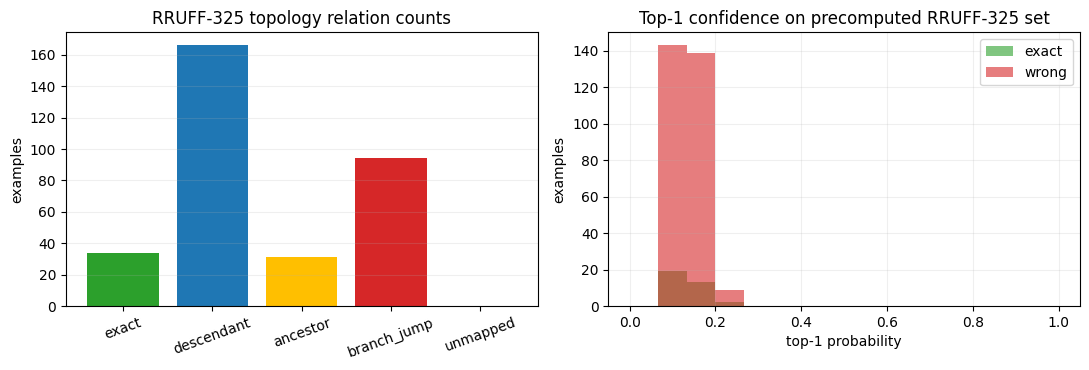

In [13]:
precomputed = load_precomputed_benchmark_summary(PRECOMPUTED_SUMMARY_PATH, bundle) if PRECOMPUTED_SUMMARY_PATH.exists() else None
if precomputed is None:
    print('Precomputed summary not found at', PRECOMPUTED_SUMMARY_PATH)
else:
    print('Loaded', precomputed['n_examples'], 'examples from', PRECOMPUTED_SUMMARY_PATH)
    display(pd.DataFrame([
        {
            'index': ex['index'],
            'case_id': ex['case_id'],
            'mineral': ex.get('mineral'),
            'true_eg': ex.get('true_eg'),
            'top1_eg': ex.get('top1_eg'),
            'top1_probability': ex.get('top1_probability'),
            'decoder': ex.get('selected_decoder'),
        }
        for ex in precomputed['examples'][:10]
    ]))
    fig, axes = plot_precomputed_summary(precomputed, topology)
    plt.show()

{
  "index": 0,
  "case_id": "Actinolite__R050336-1__5330",
  "mineral": "Actinolite",
  "true_eg": 5,
  "rwp": 0.16142818331718445,
  "severity": "recoverable",
  "fit_bucket": "fail",
  "selected_decoder": "aux_bayes",
  "top1_eg": 4,
  "top1_symbol": "P 42/n - -",
  "top1_candidate_space_groups": [
    14
  ],
  "top1_probability": 0.13948173820972443,
  "top5_eg": [
    4,
    5,
    75,
    99,
    17
  ],
  "top5_prob": [
    0.13948173820972443,
    0.10603079199790955,
    0.08679603040218353,
    0.08190206438302994,
    0.0716211125254631
  ]
}
Topology relation: branch_jump
Shortest-path distance: 3
Condensed DAG path: ['4', '0', '2', '3']


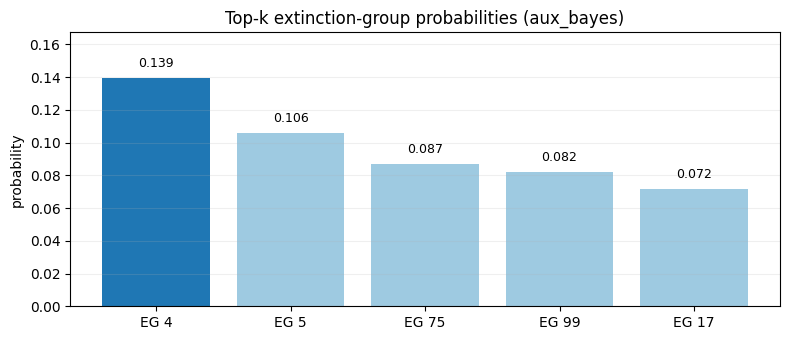

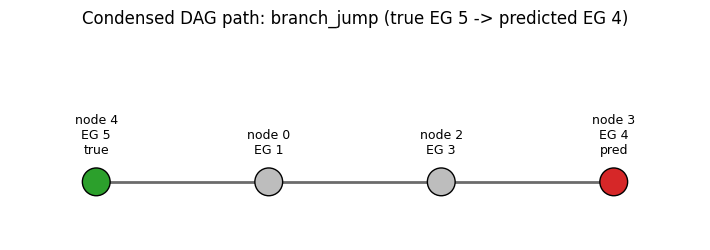

In [14]:
PRECOMPUTED_INDEX = 0
if precomputed is not None:
    ex = precomputed['examples'][PRECOMPUTED_INDEX]
    relation = describe_topology_relation(int(ex['top1_eg']), int(ex['true_eg']), topology)
    print(json.dumps(ex, indent=2))
    print('Topology relation:', relation['relation'])
    print('Shortest-path distance:', relation['distance'])
    print('Condensed DAG path:', relation['path'])
    _result = {
        'selected_decoder': ex['selected_decoder'],
        'decoders': {
            ex['selected_decoder']: {
                'top5_eg': ex['top5_eg'],
                'top5_prob': ex['top5_prob'],
            }
        }
    }
    fig, ax = plot_topk_probabilities(_result)
    plt.show()
    fig, ax = plot_topology_path(relation, topology, true_eg=int(ex['true_eg']), pred_eg=int(ex['top1_eg']))
    plt.show()